## STEP 1: Importing relevant libraries

In [3]:
# Import relevant libraries   
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt



## STEP 2: Loading the dataset

In [4]:
# Reading the supplements dataset
sales_data = pd.read_excel("/Users/luxdevhq/Desktop/Data Science CH07/EDA/data/dirty_supplement_sales_data_2020.xlsx")

## STEP 3: Inspecting Data

In [5]:
# View the top 5 rows  
print(f"Top 5 rows:  {display(sales_data.head())}")  

# Viewing the last 5 rows  
print(f"Last 5 rows: {display(sales_data.tail())}")

,Date,Product Category,Product Name,Units Sold,Units Returned,Price,Discount (%),Revenue,Platform,Location
0,2020-10-07,Sleep Aids,ImmunoPro,NaN,1.0,$10.99,105.0,0.000,Instore,Los Angeles
1,2020-09-16,Vitamins,MuscleMax,NaN,-1.0,NaN,0.0,NaN,Mob App,Houston
2,2020-11-11,Immunity Boosters,Slim F@st,15.0,-1.0,15,NaN,225.000,Online,Chicago
3,2020-11-04,Energy Drinks,PowerFuel,14.0,0.0,$10.99,25.0,115.395,Online,new york
4,2020-06-03,Vitamins,SuperV!ta,NaN,NaN,$10.99,50.0,0.000,Mobile App,new york


Top 5 rows:  None


,Date,Product Category,Product Name,Units Sold,Units Returned,Price,Discount (%),Revenue,Platform,Location
3095,2020-09-16,Immunity Boosters,SuperV!ta,10.0,2.0,NaN,25.0,NaN,In-Store,Chicago
3096,2020-08-12,Vitamins,DreamRest,25.0,0.0,NaN,25.0,NaN,onlien,New York
3097,2020-10-21,Immunity Boosters,SuperV!ta,NaN,-1.0,$10.99,25.0,0.0,Mobile App,Chi-Town
3098,2020-02-19,Weight Loss,SuperVita,NaN,NaN,NaN,NaN,NaN,Instore,Chicago
3099,2020-08-26,Protein,PowerFuel,NaN,0.0,15,0.0,0.0,Mobile App,Phoenix


Last 5 rows: None


__Inspecting the shape of the dataset__

In [6]:
sales_data.shape

(3100, 10)

__Inspecting summary information about the dataset__

In [7]:
sales_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              3100 non-null   str    
 1   Product Category  3100 non-null   str    
 2   Product Name      3100 non-null   str    
 3   Units Sold        1551 non-null   float64
 4   Units Returned    2495 non-null   float64
 5   Price             2457 non-null   object 
 6   Discount (%)      2651 non-null   float64
 7   Revenue           2457 non-null   float64
 8   Platform          3100 non-null   str    
 9   Location          3100 non-null   str    
dtypes: float64(4), object(1), str(5)
memory usage: 242.3+ KB


__Inspecting summary statistics__   

_Numerical Columns_


In [8]:
sales_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Units Sold,1551.0,24.514507,14.398598,1.0,11.5,24.0,37.0,50.0
Units Returned,2495.0,0.478557,1.120023,-1.0,-1.0,0.0,1.0,2.0
Discount (%),2651.0,35.403621,35.162792,0.0,10.0,25.0,50.0,105.0
Revenue,2457.0,101.290307,159.300390,-37.5,0.0,0.0,180.0,735.0


_Categorical Columns_

In [9]:
sales_data.describe(include='object').T  # If you're using current versions of pandas use 'str' instead of 'object'

/var/folders/fh/dnmx2fzs5w16_qp8qtg223480000gn/T/ipykernel_7413/810858553.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  sales_data.describe(include='object').T  # If you're using current versions of pandas use 'str' instead of 'object'


,count,unique,top,freq
Date,3100,104,2020-05-20,68
Product Category,3100,6,Protein,555
Product Name,3100,8,Slim F@st,409
Price,2457,4,12.50 USD,642
Platform,3100,6,Instore,537
Location,3100,8,L.A.,421


__Inspecting the columns in the dataset__

In [10]:
sales_data.columns

Index(['Date', 'Product Category', 'Product Name', 'Units Sold',
       'Units Returned', 'Price', 'Discount (%)', 'Revenue', 'Platform',
       'Location'],
      dtype='str')

__Inspecting data types in the dataset__    

In [11]:
sales_data.dtypes

Date                    str
Product Category        str
Product Name            str
Units Sold          float64
Units Returned      float64
Price                object
Discount (%)        float64
Revenue             float64
Platform                str
Location                str
dtype: object

__Inspecting missing values__

In [12]:
sales_data.isnull().sum()

Date                   0
Product Category       0
Product Name           0
Units Sold          1549
Units Returned       605
Price                643
Discount (%)         449
Revenue              643
Platform               0
Location               0
dtype: int64

## STEP 4: Data Cleaning
 ### 4.1 Standardize Column  names   
Column names should be clean, readable, and consistent.   

_Why Standardisation Matters_  
- Prevents Code Errors: Programming languages like Python can fail if column names contain hidden spaces, trailing whitespaces, or special characters.
- Simplifies Merging: Joining datasets requires matching key columns; different names (e.g., user_id vs UserID) break automated joins.
- Speeds Up Queries: Consistent names allow you to write reusable code, macros, and templates without rewriting scripts for every new file.
- Improves Tool Automation: Modern BI tools (like Tableau or Power BI) and AI models automatically detect relationships when names match across tables.
- Enhances Readability: Clean, uniform names make it easy for teammates to understand the schema without reading data dictionaries.   

_Common Standardisation Practices_   
- Use lowercase letters exclusively (customer_id instead of CustomerID).  
- Replace spaces with underscores (order_date instead of Order Date).   




In [13]:
# Standardizing the sales column names  
# 1. Strip any preceding spaces
sales_data.columns = sales_data.columns.str.strip() 

# 3. Set the column names to lowercase  
sales_data.columns = sales_data.columns.str.lower()   



# 4. Remove any spaces between words and replace with underscores  
sales_data.columns = sales_data.columns.str.replace(" ", "_")  


In [14]:
# 2. Remove the percentage sign on the 'Discount (%)' and update to discount percentage

sales_data = sales_data.rename(columns = {"discount_(%)":"discount_percentage"})




In [15]:
sales_data.columns

Index(['date', 'product_category', 'product_name', 'units_sold',
       'units_returned', 'price', 'discount_percentage', 'revenue', 'platform',
       'location'],
      dtype='str')

__Note:__ Instead of writing individual conversion, you can use the code below:  
```python
sales_data.columns = sales_data.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('_(%)', '_percent', regex=False).str.replace('(%)', 'percent', regex=False)
```  
`regex=False`  
- RegEx (short for Regular Expression) is a sequence of special characters that forms a search pattern  
- Setting regex=False tells the search or filter function to treat the search term as a literal string rather than a complex pattern. Without this, special characters (like . or *) are treated as active RegEx commands, which can cause unexpected errors.


### 4.2 Standardise data types

Common data types:  
- Text/Object = names, categories, locations  
- Integer = whole numbers
- Float = decimal numbers
- Date/Datetime = dates and times
- Boolean = True/False values

Common problems:  

- Dates stored as text
- Numbers stored as text
- Currency values stored with symbols
- Percentages stored as text
- Yes/No values stored inconsistently

_Date column_

In [16]:
# Check the unique date formats  
sales_data["date"].unique()  

# This is important before converting the dates column into date data type as it gives you a clear overview of how your dates column looks like. 
# Converting before checking the formats might cause errors or removal of existing dates

<StringArray>
['2020-10-07', '2020-09-16', '2020-11-11', '2020-11-04', '2020-06-03',
 '2020-09-09', '2020-06-17', '2020-09-23', '2020-10-28', '2020-04-01',
 ...
 '10/06/2020', '12/08/2020', '04/11/2020', '08/01/2020', '04/03/2020',
 '29/07/2020', '11/03/2020', '28/10/2020', '23/12/2020', '08/07/2020']
Length: 104, dtype: str

In [17]:
# Convert the date column to a datetime format  
sales_data["date"] = pd.to_datetime(sales_data["date"], format='mixed', errors='coerce')

In [18]:
sales_data.dtypes

date                   datetime64[us]
product_category                  str
product_name                      str
units_sold                    float64
units_returned                float64
price                          object
discount_percentage           float64
revenue                       float64
platform                          str
location                          str
dtype: object

In [19]:
# Check the unique entries in the price column  
sales_data['price'].unique()

array(['$10.99', nan, 15, '12.50 USD', 9.99], dtype=object)

In [20]:
# Dropping the dollar sign and the USD str
sales_data["price"] = sales_data["price"].astype(str).str.replace(r'[^0-9.]', '', regex=True)  

# Convert the price column to numeric datatype   
sales_data["price"] = pd.to_numeric(sales_data["price"], errors='coerce')

- ```.astype(str)```: Converts the entire column into text (strings) so that string-specific manipulation methods can be used.  
- ```.str.replace(...)```: Searches the text for specific patterns and replaces them.  
- ```r'[^0-9.]'```: This is a regular expression (regex).The ^ inside the brackets means "NOT".   
- It translates to: _"Find anything that is not a number (0-9) and not a decimal point (.)"_.  
- ``''``: This replaces all the matched unwanted characters with an empty string (meaning they are deleted).,   
- ```regex=True```: Tells the replace function to use regex matching rather than looking for an exact text match.

In [21]:
sales_data.dtypes

date                   datetime64[us]
product_category                  str
product_name                      str
units_sold                    float64
units_returned                float64
price                         float64
discount_percentage           float64
revenue                       float64
platform                          str
location                          str
dtype: object

*units_returned column*  
There are negative entries in the units_returns which in reality there's no negative good

In [22]:
sales_data["units_returned"] = sales_data["units_returned"].abs()

In [23]:
sales_data.head()

,date,product_category,product_name,units_sold,units_returned,price,discount_percentage,revenue,platform,location
0,2020-10-07,Sleep Aids,ImmunoPro,NaN,1.0,10.99,105.0,0.000,Instore,Los Angeles
1,2020-09-16,Vitamins,MuscleMax,NaN,1.0,NaN,0.0,NaN,Mob App,Houston
2,2020-11-11,Immunity Boosters,Slim F@st,15.0,1.0,15.00,NaN,225.000,Online,Chicago
3,2020-11-04,Energy Drinks,PowerFuel,14.0,0.0,10.99,25.0,115.395,Online,new york
4,2020-06-03,Vitamins,SuperV!ta,NaN,NaN,10.99,50.0,0.000,Mobile App,new york


### 4.3 Check for Duplicates  and drop them if any


In [24]:
# Check number of duplicates
print(f"Number of duplicate rows: {sales_data.duplicated().sum()}")  


Number of duplicate rows: 100


__Drop duplicated rows__

In [25]:
sales_data = sales_data.drop_duplicates()
print(f"Number of duplicate rows after: {sales_data.duplicated().sum()}")

Number of duplicate rows after: 0


### 4.4 Handling Categorical columns entries

In [26]:
# Listing categorical columns  
categorical_cols = sales_data.select_dtypes(include=["object"]).columns.to_list()

categorical_cols   

for column in categorical_cols:
    print("=" * 70)

    print(f"Unique categories in '{column}'")

    print(sales_data[column].unique())

Unique categories in 'product_category'
<StringArray>
[       'Sleep Aids',          'Vitamins', 'Immunity Boosters',
     'Energy Drinks',       'Weight Loss',           'Protein']
Length: 6, dtype: str
Unique categories in 'product_name'
<StringArray>
['ImmunoPro', 'MuscleMax', 'Slim F@st', 'PowerFuel', 'SuperV!ta', 'SuperVita',
 'DreamRest',  'SlimFast']
Length: 8, dtype: str
Unique categories in 'platform'
<StringArray>
['Instore', 'Mob App', 'Online', 'Mobile App', 'In-Store', 'onlien']
Length: 6, dtype: str
Unique categories in 'location'
<StringArray>
['Los Angeles',     'Houston',     'Chicago',    'new york',     'Phoenix',
    'New York',    'Chi-Town',        'L.A.']
Length: 8, dtype: str


/var/folders/fh/dnmx2fzs5w16_qp8qtg223480000gn/T/ipykernel_7413/3000398646.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = sales_data.select_dtypes(include=["object"]).columns.to_list()


__Clean product_name, platform, and location__   

*product_name*  
Clean the product_name column and unify the product names i.e  'Slim F@st' should be  'SlimFast', 'SuperV!ta' should be 'SuperVita'

In [27]:
sales_data["product_name"] = sales_data["product_name"].replace({'Slim F@st' : 'SlimFast', 
                                                                'SuperV!ta' : 'SuperVita'})

_platform_  
Clean and unify the platform column categories i.e 'In-Store' should be 'Instore', 'onlien' should be 'Online', 'Mob App' should be 'Mobile App'

In [28]:
sales_data['platform'] = sales_data['platform'].replace({'In-Store':'Instore',
                                                        'Mob App' : 'Mobile App',
                                                        'onlien' : 'Online'})

_location_  
Clean and unify the location column categories i.e 'L.A.' should be 'Los Angeles', 'Chi-Town' should be 'Chicago', 'new york' should be 'New York'

In [29]:
sales_data['location'] = sales_data['location'].replace({'Chi-Town':'Chicago',
                                                        'new york' : 'New York',
                                                        'L.A.' : 'Los Angeles'})

__Confirm implementation of changes__  


In [30]:
for column in categorical_cols:
    print("=" * 70)

    print(f"Unique categories in '{column}'")

    print(sales_data[column].unique())

Unique categories in 'product_category'
<StringArray>
[       'Sleep Aids',          'Vitamins', 'Immunity Boosters',
     'Energy Drinks',       'Weight Loss',           'Protein']
Length: 6, dtype: str
Unique categories in 'product_name'
<StringArray>
['ImmunoPro', 'MuscleMax', 'SlimFast', 'PowerFuel', 'SuperVita', 'DreamRest']
Length: 6, dtype: str
Unique categories in 'platform'
<StringArray>
['Instore', 'Mobile App', 'Online']
Length: 3, dtype: str
Unique categories in 'location'
<StringArray>
['Los Angeles', 'Houston', 'Chicago', 'New York', 'Phoenix']
Length: 5, dtype: str


### 4.5 Handling Missing Values  
There is no single correct method. It depends on the column and the business context.   
#### Step 1: Try and calculate from the other columns.   
_i). Revenue_  
${Revenue} = \left(\left(1 - \frac{\%Discount}{100}\right) \times \text{Price}\right) \times \text{Units Sold}$

_ii). Price_  
${Price}=\frac{\text{Revenue}}{\left(1-\frac{\%Discount}{100}\right)\times \text{Units\ Sold}}$  

_iii). Units Sold_  
${Units\ Sold}=\frac{\text{Revenue}}{\left(1-\frac{\%Discount}{100}\right)\times \text{Price}}$  

_iv) Discount Perecentage_. 

$(\%Discount = 100 \times \left(1 - \frac{\text{Revenue}}{\text{Price} \times \text{Units Sold}}\right)$





In [31]:
sales_data.isnull().sum()

date                      0
product_category          0
product_name              0
units_sold             1492
units_returned          587
price                   613
discount_percentage     434
revenue                 613
platform                  0
location                  0
dtype: int64

In [32]:
import numpy as np

def calculate_financials(row):
    # 'row' represents a single horizontal record (line) of data from the DataFrame.
    # We unpack the specific column values into short variables for easier math formulas.
    u, p, d, r = row['units_sold'], row['price'], row['discount_percentage'], row['revenue']
    
    # 1. Reset abnormal discounts to try and recalculate them
    # If a discount exists but is unrealistic (over 100% or below 0%), we wipe it out
    # to see if we can reverse-engineer a proper discount rate from the other columns.
    if pd.notna(d) and (d > 100 or d < 0):
        d = np.nan

    # 2. Sequential Formula Fallbacks
    
    # CASE A: Calculate REVENUE
    # Triggered when: Revenue is missing, but Units, Price, and Discount are all known.
    # Formula: Revenue = (1 - Discount Rate) * Price * Quantity
    if pd.isna(r) and pd.notna(u) and pd.notna(p) and pd.notna(d):
        r = (1 - d/100) * p * u
        
    # CASE B: Calculate UNITS SOLD
    # Triggered when: Units Sold is missing, but Revenue, Price, and Discount are all known.
    elif pd.isna(u) and pd.notna(r) and pd.notna(p) and pd.notna(d):
        # We calculate the discounted price per single unit first (the denominator).
        denom = (1 - d/100) * p
        # If the discounted price is normal (not 0), we divide total revenue by unit price to get units.
        # If it is 0, we check revenue: if revenue is 0, units must be 0; otherwise, set to NaN to avoid a crash.
        u = r / denom if denom != 0 else (0.0 if r == 0 else np.nan)
        
    # CASE C: Calculate ORIGINAL PRICE
    # Triggered when: Price is missing, but Revenue, Units Sold, and Discount are all known.
    elif pd.isna(p) and pd.notna(r) and pd.notna(u) and pd.notna(d):
        # We calculate total units factoring in the discount fraction (the denominator).
        denom = (1 - d/100) * u
        # Formula: Original Price = Revenue / (Discounted Units Quantity)
        # We include a safety check to ensure we don't divide by 0 if units sold was 0.
        p = r / denom if denom != 0 else np.nan
        
    # CASE D: Calculate DISCOUNT PERCENTAGE
    # Triggered when: Discount is missing, but Revenue, Price, and Units Sold are all known.
    elif pd.isna(d) and pd.notna(r) and pd.notna(p) and pd.notna(u):
        # Gross sales represents what total revenue would be with NO discounts applied.
        u_p = u * p
        # Formula: Discount % = 100 * (1 - (Actual Revenue / Gross Potential Revenue))
        # If gross sales is 0, we can't divide, so we safely return NaN.
        d = 100 * (1 - r / u_p) if u_p != 0 else np.nan

    # 3. Update the row with calculated values (or original NaNs if calculation wasn't possible)
    # We map our newly calculated (or untouched) variables back into the original row structure.
    row['units_sold'], row['price'], row['discount_percentage'], row['revenue'] = u, p, d, r
    
    # Return the fully modified row back to the pandas processing loop

    return row

# Apply the calculation function row-by-row (axis=1 means processing rows, not columns)
sales_data = sales_data.apply(calculate_financials, axis=1)

# Check and print the total count of remaining missing values for each column
print(sales_data.isnull().sum())

# Preview the top 5 records of the updated dataset in the notebook environment
print(display(sales_data.head()))


date                     0
product_category         0
product_name             0
units_sold             639
units_returned         587
price                  613
discount_percentage    539
revenue                613
platform                 0
location                 0
dtype: int64


,date,product_category,product_name,units_sold,units_returned,price,discount_percentage,revenue,platform,location
0,2020-10-07,Sleep Aids,ImmunoPro,NaN,1.0,10.99,NaN,0.000,Instore,Los Angeles
1,2020-09-16,Vitamins,MuscleMax,NaN,1.0,NaN,0.0,NaN,Mobile App,Houston
2,2020-11-11,Immunity Boosters,SlimFast,15.0,1.0,15.00,0.0,225.000,Online,Chicago
3,2020-11-04,Energy Drinks,PowerFuel,14.0,0.0,10.99,25.0,115.395,Online,New York
4,2020-06-03,Vitamins,SuperVita,0.0,NaN,10.99,50.0,0.000,Mobile App,New York


None


#### Step 2: Check the proportions of the nulls

In [33]:
nulls_proportions = ((sales_data.isnull().sum()/len(sales_data)) * 100)

nulls_proportions


date                    0.000000
product_category        0.000000
product_name            0.000000
units_sold             21.300000
units_returned         19.566667
price                  20.433333
discount_percentage    17.966667
revenue                20.433333
platform                0.000000
location                0.000000
dtype: float64

In [34]:
sales_data.dtypes

date                   datetime64[us]
product_category                  str
product_name                      str
units_sold                    float64
units_returned                float64
price                         float64
discount_percentage           float64
revenue                       float64
platform                          str
location                          str
dtype: object

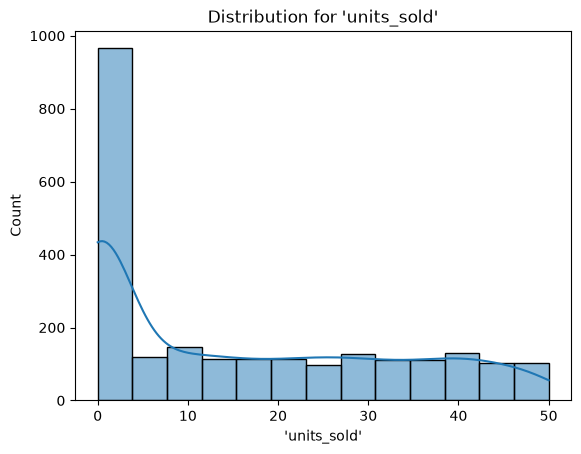

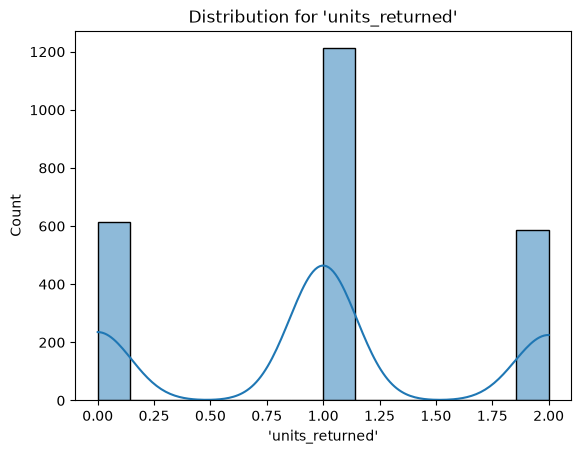

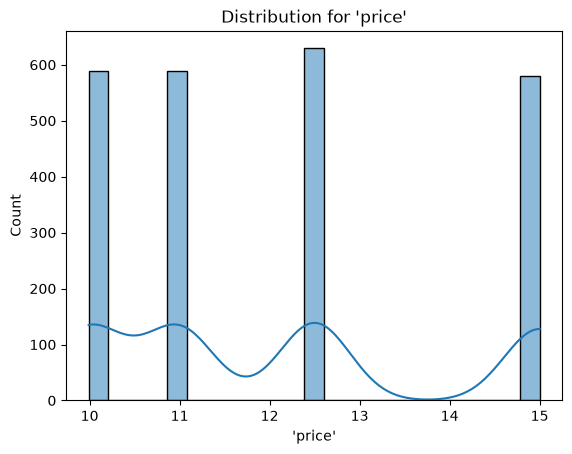

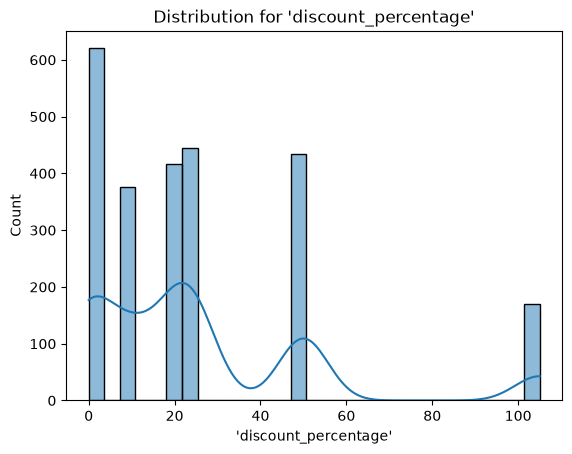

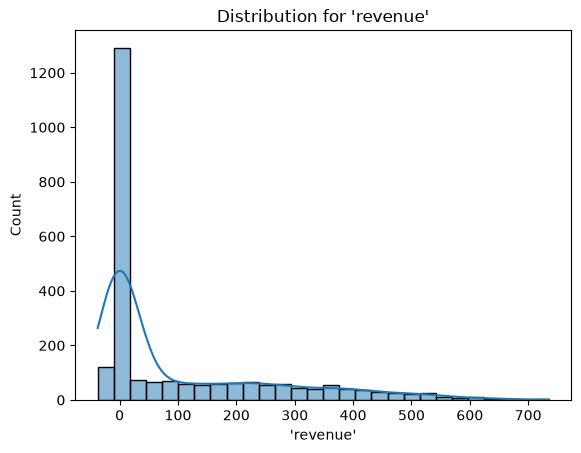

In [35]:
# Check for the distributions of the columns 
# Select columns
numerical_cols = sales_data.select_dtypes(include=["float", "int"]).columns.to_list()
numerical_cols  

# Plot
for col in numerical_cols:
    sns.histplot(sales_data, x=col, kde=True)
    plt.title(f"Distribution for '{col}'")
    plt.xlabel(f"'{col}'")
    plt.show()

__Fill the nulls with median__

In [36]:
for col in numerical_cols:
    median = sales_data[col].median()
    sales_data[col] = sales_data[col].fillna(median)

sales_data.isnull().sum()

date                   0
product_category       0
product_name           0
units_sold             0
units_returned         0
price                  0
discount_percentage    0
revenue                0
platform               0
location               0
dtype: int64

In [37]:
sales_data.head()

,date,product_category,product_name,units_sold,units_returned,price,discount_percentage,revenue,platform,location
0,2020-10-07,Sleep Aids,ImmunoPro,11.0,1.0,10.99,20.0,0.000,Instore,Los Angeles
1,2020-09-16,Vitamins,MuscleMax,11.0,1.0,12.50,0.0,0.000,Mobile App,Houston
2,2020-11-11,Immunity Boosters,SlimFast,15.0,1.0,15.00,0.0,225.000,Online,Chicago
3,2020-11-04,Energy Drinks,PowerFuel,14.0,0.0,10.99,25.0,115.395,Online,New York
4,2020-06-03,Vitamins,SuperVita,0.0,1.0,10.99,50.0,0.000,Mobile App,New York


__Check the final shape of the dataset__


In [38]:
sales_data.shape


(3000, 10)

## STEP 5: Save the final clean dataset. 

In [39]:
# import os
# os.mkdir("../data/processed") 
sales_data.to_csv("../data/processed/clean_sales_data.csv", index=False)

# EDA: Exploratory Data Analsis. 
### Business questions to answer. 
- Which product categories generate the highest revenue weekly?
- What is the average revenue per unit sold across all platforms?
- Can optimizing discount rates improve units sold without significantly reducing revenue?
- What platform consistently drives the most units sold and should be prioritized in marketing?

_i). Which product categories generate the highest revenue weekly?_  
Visualization 1: Average weekly revenue by category

In [ ]:
# Create week column
sales_data["week"] = sales_data["date"].dt.to_period("W").apply(lambda x: x.start_time)

# Create revenue per unit column
sales_data["revenue_per_unit"] = sales_data["revenue"] / sales_data["units_sold"]

    product_category     revenue
0            Protein  892.320365
1  Immunity Boosters  804.419442
2      Energy Drinks  783.907817
3         Sleep Aids  751.953269
4        Weight Loss  727.950885
5           Vitamins  704.973269


/var/folders/fh/dnmx2fzs5w16_qp8qtg223480000gn/T/ipykernel_7413/3893520998.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


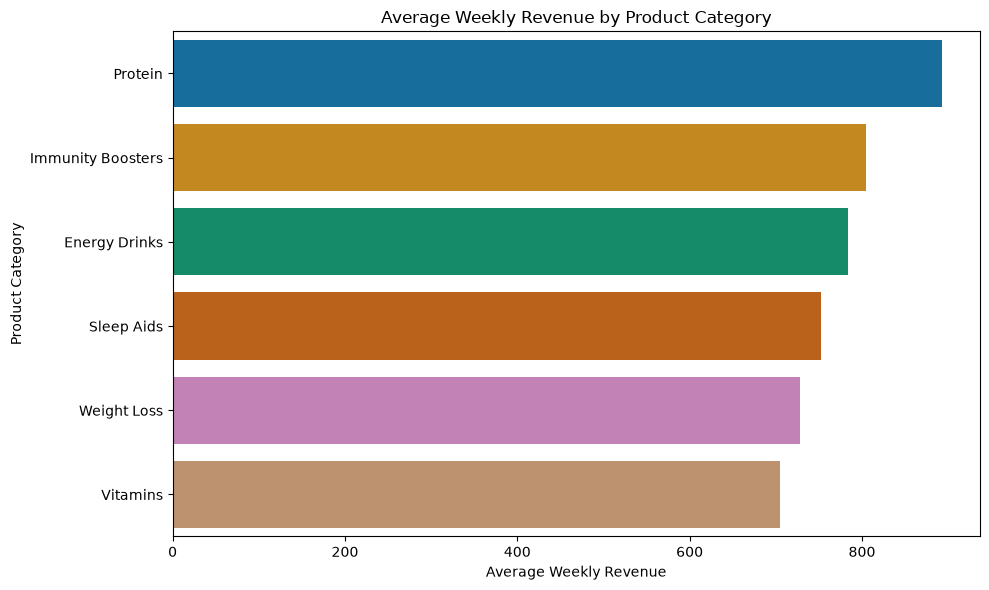

In [47]:
# Weekly revenue by product category
weekly_category_revenue = (
    sales_data.groupby(["week", "product_category"])["revenue"]
    .sum()
    .reset_index()
)

# Average weekly revenue by category
avg_weekly_category_revenue = (
    weekly_category_revenue
    .groupby("product_category")["revenue"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print(avg_weekly_category_revenue) 

# Plot

plt.figure(figsize=(10, 6))
sns.barplot(
    data=avg_weekly_category_revenue,
    x="revenue",
    y="product_category",
    palette="colorblind"
)

plt.title("Average Weekly Revenue by Product Category")
plt.xlabel("Average Weekly Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

Visualization 2: Weekly revenue trend by category

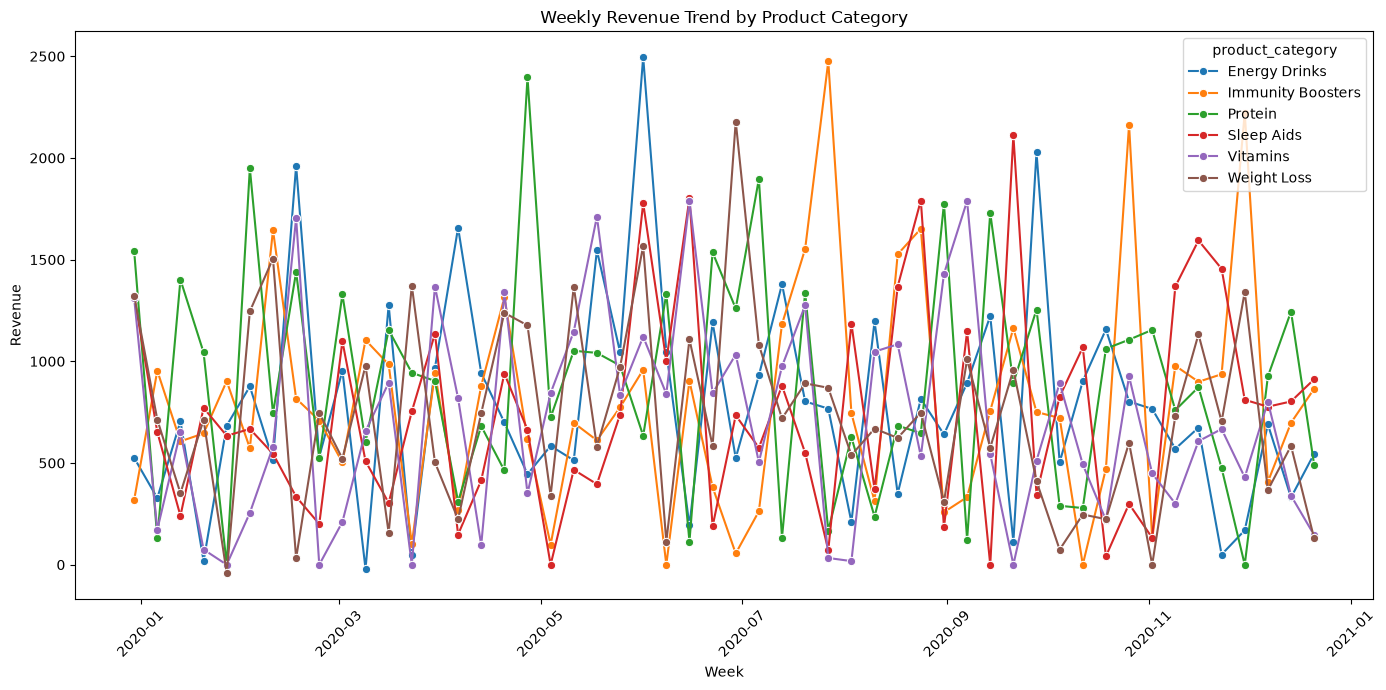

In [51]:
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=weekly_category_revenue,
    x="week",
    y="revenue",
    hue="product_category",
    marker="o",
)

plt.title("Weekly Revenue Trend by Product Category")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

__Conclusion:__ Protein appears to be the strongest revenue-generating category weekly.

_ii). What is the average revenue per unit sold across all platforms?_

In [52]:
# 1. Overall average revenue per unit
overall_rev_per_unit = sales_data["revenue"].sum() / sales_data["units_sold"].sum()
print(f"Overall Average Revenue Per Unit: {overall_rev_per_unit:.2f}")

# 2. Average revenue per unit by platform
platform_grouped = sales_data.groupby("platform")[["revenue", "units_sold"]].sum()
platform_rev_per_unit = (
    (platform_grouped["revenue"] / platform_grouped["units_sold"])
    .sort_values(ascending=False)
    .reset_index(name="avg_revenue_per_unit")
)
print(platform_rev_per_unit)


Overall Average Revenue Per Unit: 5.50
     platform  avg_revenue_per_unit
0      Online              5.724694
1     Instore              5.542082
2  Mobile App              5.229022


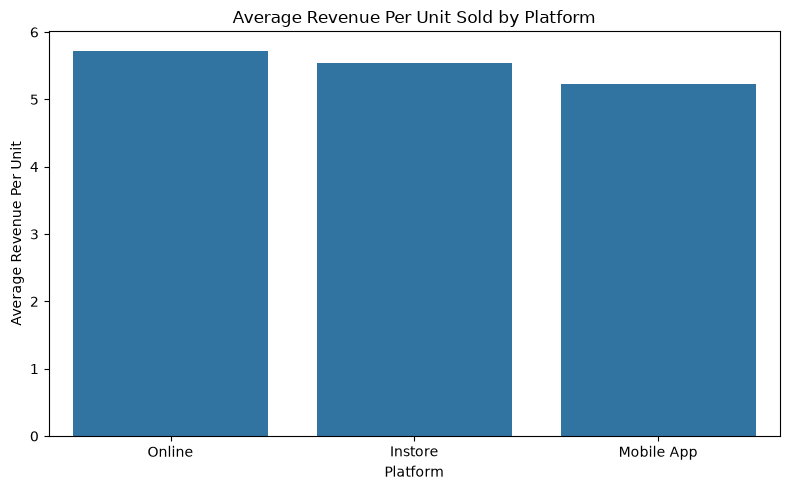

In [54]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=platform_rev_per_unit,
    x="platform",
    y="avg_revenue_per_unit"
)

plt.title("Average Revenue Per Unit Sold by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Revenue Per Unit")
plt.tight_layout()
plt.show()

__Conclusion:__ This means the Online platform generates better revenue per unit sold compared to the other platforms.

_iii). What platform consistently drives the most units sold and should be prioritized in marketing?_


     platform  units_sold
0     Instore     14996.0
1      Online     14806.0
2  Mobile App     14293.0


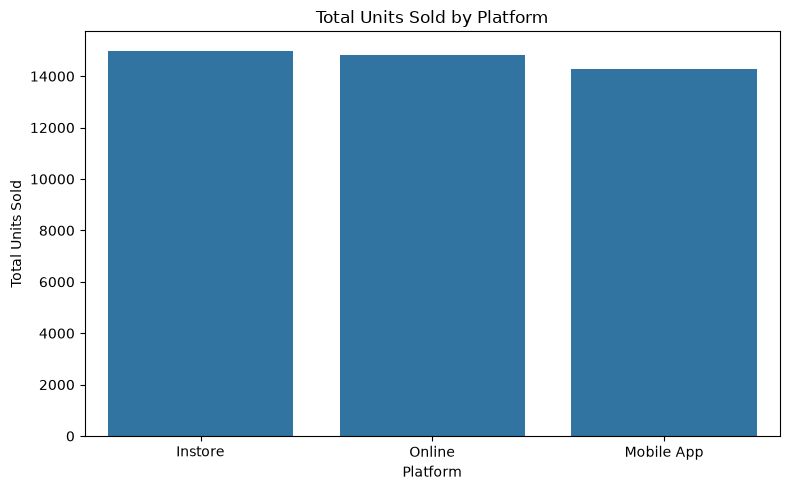

In [60]:
# Total units sold by platform
platform_units = (
    sales_data.groupby("platform")["units_sold"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(platform_units)

# Plot Visualization 1: Total units sold by platform
plt.figure(figsize=(8, 5))
sns.barplot(
    data=platform_units,
    x="platform",
    y="units_sold"
)

plt.title("Total Units Sold by Platform")
plt.xlabel("Platform")
plt.ylabel("Total Units Sold")
plt.tight_layout()
plt.show()

__Conclusion:__ Instore has the highest total units sold.

In [43]:
sales_data.head()


,date,product_category,product_name,units_sold,units_returned,price,discount_percentage,revenue,platform,location,week,revenue_per_unit
0,2020-10-07,Sleep Aids,ImmunoPro,11.0,1.0,10.99,20.0,0.000,Instore,Los Angeles,2020-10-05,0.0000
1,2020-09-16,Vitamins,MuscleMax,11.0,1.0,12.50,0.0,0.000,Mobile App,Houston,2020-09-14,0.0000
2,2020-11-11,Immunity Boosters,SlimFast,15.0,1.0,15.00,0.0,225.000,Online,Chicago,2020-11-09,15.0000
3,2020-11-04,Energy Drinks,PowerFuel,14.0,0.0,10.99,25.0,115.395,Online,New York,2020-11-02,8.2425
4,2020-06-03,Vitamins,SuperVita,0.0,1.0,10.99,50.0,0.000,Mobile App,New York,2020-06-01,NaN


### TakeAway Practice Tasks. 
Explore, visualize and give findings on the following business questions.  
1. Univariate Analysis  
    - What is the most common product category sold?
    - What is the most common sales platform?
    - What is the distribution of product prices?
    - What is the distribution of discount percentages?
    - Which products appear most frequently in the dataset? 
2. Bivariate Analysis. 
    - Which product category generates the highest total revenue?
    - Which platform sells the most units?
    - Which location generates the highest revenue?
    - Does a higher discount lead to more units sold?
    - Do higher prices reduce the number of units sold?
    - Are returned units associated with lower revenue? 

3. Multivariate Analysis.  
    - Which product category performs best on each platform?
    - Which location performs best for each platform?
    - Which category-platform combination generates the highest revenue?
    - Which location-platform combination sells the most units?
    - How does discount percentage affect revenue across different product categories?
    - How does price affect units sold across different platforms?
    - Which products perform best when considering revenue, units sold, platform, and location together?
